# Inspection of variables after Full Selection

**_run with dfs created with the full selection_**

This notebook inspects the selected events after the full event selection 

In [1]:
%load_ext autoreload
%autoreload 2

In [16]:
from os import path, makedirs
from datetime import datetime
from functools import partial

import numpy as np
import pandas as pd

import sys
sys.path.append('../../')
from pyanalib.split_df_helpers import *
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
plt.style.use("presentation.mplstyle")

In [3]:
save_fig = False

save_fig_base_dir = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi"
today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, "selected_events-{}".format(today_str))

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

# Load dfs

In [4]:
import string
def generate_tags(end_tag=""):
    tags = []
    for first in string.ascii_lowercase:
        for second in string.ascii_lowercase:
            tag = first + second
            if tag == end_tag:
                break
            tags.append(tag)
        if tag == end_tag:
            break
    return tags

In [5]:
n_max_concat = 3
file_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09"

## -- MC 
mc_keys2load = ['hdr', 'evt'] 
concat_dfs = load_and_concat_mc_dfs(
    file_dir=file_dir,
    chunk_tags=generate_tags("bl"),
    df_tag="",
    keys2load=mc_keys2load,
    n_max_concat=n_max_concat,
    sub_dir="MC",
    sample_dir="BNB_cosmics"
)
mc_hdr_df = concat_dfs['hdr']
mc_evt_df = concat_dfs['evt']

## -- low E MC

## -- Data
data_file = path.join(file_dir, "data", "BNB", "mup.df")
data_split_df = pd.read_hdf(data_file, key="split")
data_n_split = get_n_split(data_file)
print("data_n_split: %d" %(data_n_split))
print_keys(data_file)
data_keys2load = ['evt', 'hdr', 'bnbpot']
data_dfs = load_dfs(data_file, data_keys2load, n_max_concat=n_max_concat)
data_evt_df = data_dfs['evt']
data_hdr_df = data_dfs['hdr']
data_bnbpot_df = data_dfs['bnbpot']

## -- Intime Data
intime_keys2load = ['hdr', 'evt']
concat_dfs = load_and_concat_mc_dfs(
    file_dir=file_dir,
    chunk_tags=generate_tags("ad"),
    df_tag="",
    keys2load=intime_keys2load,
    n_max_concat=n_max_concat,
    sub_dir="data",
    sample_dir="OffBeam"
)
intime_hdr_df = concat_dfs['hdr']
intime_evt_df = concat_dfs['evt']

Reading file with tag aa, mc_n_split: 1
Reading file with tag ab, mc_n_split: 1
Reading file with tag ac, mc_n_split: 1
Reading file with tag ad, mc_n_split: 1
Reading file with tag ae, mc_n_split: 1
Reading file with tag af, mc_n_split: 1
Reading file with tag ag, mc_n_split: 1
Reading file with tag ah, mc_n_split: 1
Reading file with tag ai, mc_n_split: 1
Reading file with tag aj, mc_n_split: 1
Reading file with tag ak, mc_n_split: 1
Reading file with tag al, mc_n_split: 1
Reading file with tag am, mc_n_split: 1
Reading file with tag an, mc_n_split: 1
Reading file with tag ao, mc_n_split: 1
Reading file with tag ap, mc_n_split: 1
Reading file with tag aq, mc_n_split: 1
Reading file with tag ar, mc_n_split: 1
Reading file with tag as, mc_n_split: 1
Reading file with tag at, mc_n_split: 1
Reading file with tag au, mc_n_split: 1
Reading file with tag av, mc_n_split: 1
Reading file with tag aw, mc_n_split: 1
Reading file with tag ax, mc_n_split: 1
Reading file with tag ay, mc_n_split: 1


In [6]:
# BNB data
data_tot_pot = data_hdr_df['pot'].sum()
print("data_tot_pot: %.3e" %(data_tot_pot))
pot_str = get_pot_str(data_tot_pot)
pot_label = f"Events / Bin (POT={pot_str})"

data_evt_df["pot_weight"] = np.ones(len(data_evt_df))
data_gates = data_hdr_df.nbnbinfo.sum()
print("data tot gates : %.3e" %(data_gates))

# BNB MC
mc_tot_pot = mc_hdr_df['pot'].sum()
print("mc_tot_pot: %.3e" %(mc_tot_pot))
mc_pot_scale = data_tot_pot / mc_tot_pot
print("mc_pot_scale: %.3e" %(mc_pot_scale))
mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))

# Intime Data
# intime_gates = intime_hdr.noffbeambnb.sum()
intime_gates = intime_hdr_df[intime_hdr_df['first_in_subrun'] == 1]['noffbeambnb'].sum()
print("intime cosmics data gates: {:.2e}".format(intime_gates))
f = 0.073
scale_intime_to_lightdata = (1-f)*data_gates/intime_gates
print("goal scale: {:.2f}".format(scale_intime_to_lightdata))
intime_evt_df["gates_weight"] = scale_intime_to_lightdata * np.ones(len(intime_evt_df))
intime_evt_df["pot_weight"] = scale_intime_to_lightdata * np.ones(len(intime_evt_df))

data_tot_pot: 5.950e+18
data tot gates : 1.251e+06
mc_tot_pot: 5.628e+20
mc_pot_scale: 1.057e-02
intime cosmics data gates: 8.34e+07
goal scale: 0.01


/tmp/ipykernel_1000903/542970757.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))
/tmp/ipykernel_1000903/542970757.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  intime_evt_df["gates_weight"] = scale_intime_to_lightdata * np.ones(len(intime_evt_df))
/tmp/ipykernel_1000903/542970757.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all c

# Distribution of Selected Events

In [18]:
eps = 1e-8
ratio = True
approval = "internal"
textloc = [0.05, 0.55]
ax_ylim_ratio = 1.6

data_vs_mc_plotter = partial(
    overlay_hists,
    mc_df=mc_evt_df,
    data_df=data_evt_df,
    intime_df=intime_evt_df,
    ax_ylim_ratio=ax_ylim_ratio,
    ratio=ratio,
    textloc=textloc,
    approval=approval,
    save_fig=save_fig, 
)

In [8]:
var_config = VariableConfig.list_all_configs(print_summary=False)
var_config = VariableConfig.muon_momentum()

plot_labels_hist = [var_config.var_labels[1], pot_label, ""]

Available VariableConfig options:
  all_events          
  muon_direction      
  muon_momentum       
  opening_angle       
  proton_direction    
  proton_momentum     
  tki_del_Tp          
  tki_del_Tp_x        
  tki_del_Tp_y        
  tki_del_alpha       
  tki_del_p           
  tki_del_phi         


In [9]:
# syst to plot
file_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09"
mcstat_syst = np.load(file_dir + "/mcstat_syst_dict.npz")
flux_syst = np.load(file_dir + "/flux_syst_dict.npz")
g4_syst = np.load(file_dir + "/g4_syst_dict.npz")
cosmics_syst = np.load(file_dir + "/cosmics_syst_dict.npz")
genie_syst = np.load(file_dir + "/genie_syst_dict.npz")

file_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_10"
detvar_syst = np.load(file_dir + "/detvar_syst_dict.npz")

# flat uncertainties
pot_frac_unc = 0.01
ntargets_frac_unc = 0.01


frac_uncert_total = np.zeros(len(var_config.bin_centers))
systs      = [mcstat_syst, genie_syst, flux_syst, g4_syst, cosmics_syst, detvar_syst]
flat_systs = [pot_frac_unc, ntargets_frac_unc]

for syst in systs:
    syst_uncert = np.sqrt(np.diag(syst[var_config.var_save_name]))
    frac_uncert_total += syst_uncert ** 2

for syst in flat_systs:
    syst_uncert = syst * np.ones(len(var_config.bin_centers))
    frac_uncert_total += syst_uncert ** 2

frac_uncert_total = np.sqrt(frac_uncert_total)
syst = frac_uncert_total

no syst provided
No syst provided


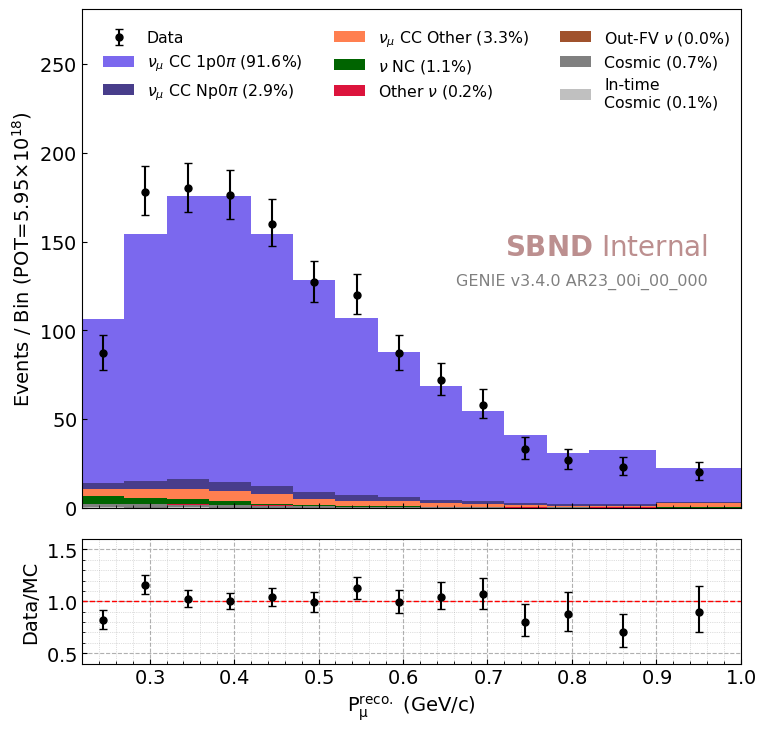

no syst provided
No syst provided


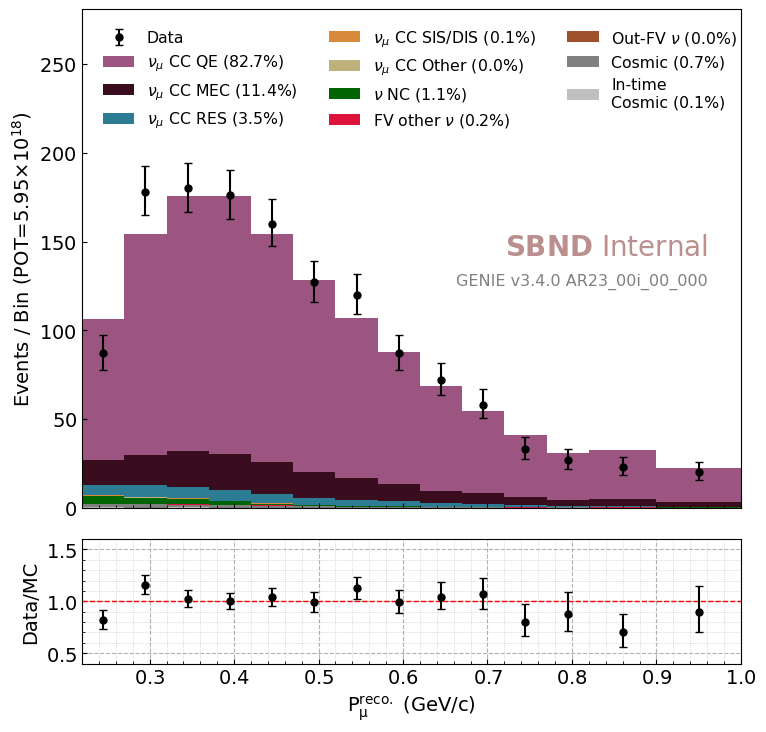

no syst provided
No syst provided


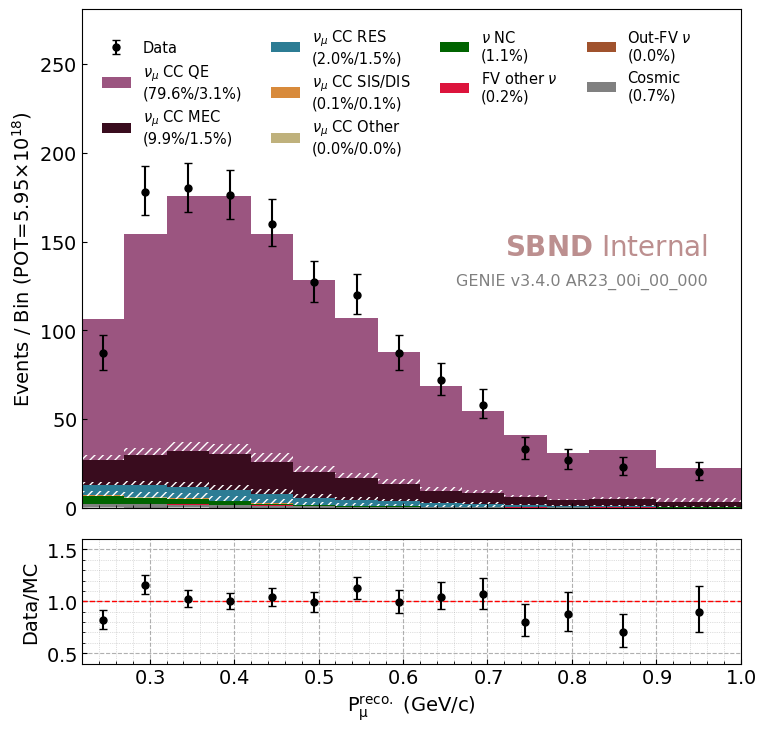

In [20]:
for breakdown_type in ["topology", "genie", "genie_sb"]:
    ret = data_vs_mc_plotter(breakdown_type=breakdown_type,
                              var_config=var_config,
                              plot_labels=plot_labels_hist,
                              syst=None,
                              save_name=path.join(save_fig_dir, "{}_{}".format(var_config.var_save_name, breakdown_type)))

# Position Breakdown

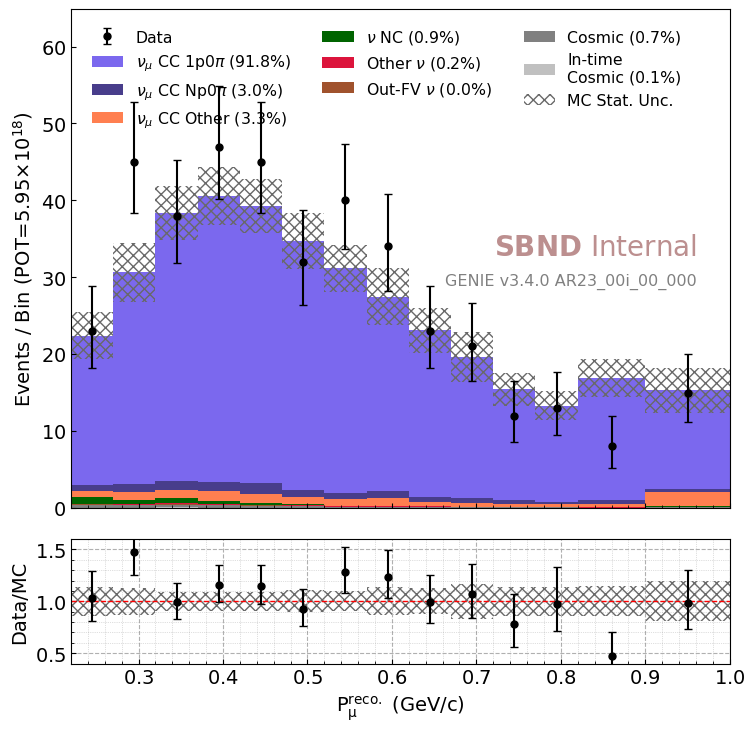

In [11]:
def position_mask(df):
    return (df.slc.vertex.z > 20) & (df.slc.vertex.z < 100)

breakdown_type = "topology"
ret = overlay_hists(breakdown_type=breakdown_type,
                        mc_df=mc_evt_df[position_mask(mc_evt_df)],
                        data_df=data_evt_df[position_mask(data_evt_df)],
                        intime_df=intime_evt_df[position_mask(intime_evt_df)],
                        var_config=var_config,
                        plot_labels=plot_labels_hist,
                        ax_ylim_ratio=ax_ylim_ratio,
                        ratio=ratio,
                        syst=syst,
                        textloc=textloc,
                        approval=approval,
                        save_fig=save_fig, 
                        save_name=path.join(save_fig_dir, "{}_{}".format(var_config.var_save_name, breakdown_type)))

## Save a portion of df

In [12]:
save_df = False

if save_df:
    tag = "slc_z_cut"
    evt_df_to_save = mc_evt_df[position_mask(mc_evt_df)]
    hdr_df_to_save = mc_hdr_df.loc[mc_evt_df.reset_index(level=[2]).index]

    evt_df_to_save.to_hdf(path.join(file_dir,"inspect-selected-{}-{}.df".format(tag, today_str)), key="evt_0")
    hdr_df_to_save.to_hdf(path.join(file_dir,"inspect-selected-{}-{}.df".format(tag, today_str)), key="hdr_0")

# Get selected event metadata for hand scanning

In [13]:
save_meta = False

if save_meta:
    colnames = ["run", "subrun", "evt"]

    topo_categ = get_topo_category(mc_evt_df)
    print(mc_evt_df.topo_categ.value_counts())

    # ===== MC =====
    # signal
    signal_meta = mc_hdr_df.loc[topo_categ[topo_categ == 1].reset_index(level=[2]).index][colnames]
    signal_meta.to_csv("signal_meta.csv", index=False)

    # cosmic
    cosmic_meta = mc_hdr_df.loc[topo_categ[topo_categ == -1].reset_index(level=[2]).index][colnames]
    cosmic_meta.to_csv("cosmic_meta.csv", index=False)

    # nu out of FV
    nu_outfv_meta = mc_hdr_df.loc[topo_categ[topo_categ == 0].reset_index(level=[2]).index][colnames]
    nu_outfv_meta.to_csv("nu_outfv_meta.csv", index=False)

    # numu cc np0pi
    numucc_np0pi_meta = mc_hdr_df.loc[topo_categ[topo_categ == 2].reset_index(level=[2]).index][colnames]
    numucc_np0pi_meta.to_csv("numucc_np0pi_meta.csv", index=False)

    # numu cc other
    numucc_other_meta = mc_hdr_df.loc[topo_categ[topo_categ == 3].reset_index(level=[2]).index][colnames]
    numucc_other_meta.to_csv("numucc_other_meta.csv", index=False)

    # numu nc
    numucc_nc_meta = mc_hdr_df.loc[topo_categ[topo_categ == 4].reset_index(level=[2]).index][colnames]
    numucc_nc_meta.to_csv("numucc_nc_meta.csv", index=False)

    # nu other
    nu_other_meta = mc_hdr_df.loc[topo_categ[topo_categ == 5].reset_index(level=[2]).index][colnames]
    nu_other_meta.to_csv("nu_other_meta.csv", index=False)

    # ===== Data =====
    data_meta = data_hdr_df.loc[data_evt_df.reset_index(level=[2]).index][colnames]
    data_meta.to_csv("data_meta.csv", index=False)

# True Topology Breakdown of Selected Events

In [14]:
# get unique combinations of final state topologies 
# and count how many events have each combination

# this_df = mc_evt_df[IsNuInFV_NumuCC_Np0pi(mc_evt_df)]
# this_df = mc_evt_df[IsNuInFV_NumuCC_Other(mc_evt_df)]
this_df = mc_evt_df.mc.copy()

particle_list = ["nmu_220MeVc", "np_300MeVc", "npi_70MeVc", "npi0"]
unique_fs = this_df[particle_list].drop_duplicates().dropna()
unique_fs_list = []
for i in unique_fs.index:
    this_fs = []
    for particle in particle_list:
        this_n_val = unique_fs.loc[i][particle].values[0]
        this_fs.append(int(this_n_val))
    unique_fs_list.append(this_fs)
print(len(unique_fs_list), "unique final state combinations")

# count how many events have each combination
n_list = []
perc_list = []
for uc in unique_fs_list:
    for pidx, particle in enumerate(particle_list):
        if pidx == 0:
            fs_mask = (this_df[particle] == uc[pidx]) 
        else:
            fs_mask = fs_mask & (this_df[particle] == uc[pidx])
    this_type_n = len(this_df[fs_mask])
    this_type_perc = this_type_n/len(mc_evt_df)
    n_list.append(this_type_n)
    perc_list.append(this_type_perc)
    print(uc, this_type_perc*100, this_type_n)

print(sum(perc_list))

47 unique final state combinations
[1, 3, 0, 0] 0.251325783022074 318
[1, 1, 0, 0] 93.707371432636 118567
[1, 2, 0, 0] 2.626275399315572 3323
[0, 1, 1, 0] 0.9499798465173992 1202
[0, 0, 1, 0] 0.10985623849078076 139
[1, 0, 0, 0] 0.49949023544009674 632
[1, 1, 0, 1] 0.20706715456535657 262
[0, 7, 2, 0] 0.0007903326510128114 1
[1, 1, 1, 0] 0.3287783828213295 416
[1, 2, 1, 0] 0.029242308087474016 37
[0, 1, 0, 0] 0.15174386899445977 192
[1, 0, 1, 0] 0.20864781986738218 264
[1, 2, 0, 1] 0.02370997953038434 30
[0, 1, 1, 2] 0.0007903326510128114 1
[0, 0, 2, 0] 0.007112993859115302 9
[1, 0, 2, 0] 0.0031613306040512456 4
[0, 1, 2, 0] 0.01185498976519217 15
[1, 0, 0, 1] 0.0031613306040512456 4
[0, 2, 1, 0] 0.03556496929557651 45
[1, 4, 0, 0] 0.021338981577345904 27
[1, 1, 0, 2] 0.0015806653020256228 2
[1, 0, 3, 0] 0.0007903326510128114 1
[1, 3, 0, 1] 0.0015806653020256228 2
[0, 2, 0, 0] 0.027661642785448397 35
[0, 2, 3, 0] 0.0007903326510128114 1
[0, 1, 2, 1] 0.0007903326510128114 1
[0, 0, 0, 0]